# 레이더 + 카메라만으로 할 수 있는 테스트 (VoD / KITTI 레이아웃)

LiDAR 포인트 클라우드(`.bin` velodyne)는 **읽지 않습니다.**  
다만 KITTI 캘리브 형식상 **카메라 투영 행렬(P)** 이 `lidar/training/calib` 또는 `radar/training/calib`의 텍스트에 들어 있으므로, 해당 **calib 파일**은 필요합니다 (VoD에서는 두 경로 모두 동일한 P를 제공하는 경우가 많음).

## 이 노트북에서 다루는 기능

1. **데이터 정합성** — 동일 프레임 ID에 대해 `image_2` · 레이더 `velodyne` · calib 존재 여부
2. **레이더 통계** — 포인트 수, 거리·RCS·도플러(상대/보정) 분포, `time`(스캔 누적) 분포
3. **카메라** — 해상도·채널·간단 히스토그램
4. **레이더 → 이미지 투영** — 3D 레이더 점을 카메라 픽셀에 올려 시각화 (동기·캘리브 검증용)
5. **시퀀스 요약** — 여러 프레임에서 레이더 포인트 개수 추이

## 실행 방법

- 터미널에서 `vod-devkit` 폴더로 이동한 뒤 Jupyter를 띄우거나, VS Code/Cursor에서 이 파일을 연 상태로 커널을 선택합니다.
- 아래 `ROOT_DIR`을 본인의 데이터 루트로 바꿉니다 (기본값: 리포에 포함된 `example_set`).
- 의존성: `numpy`, `matplotlib` (기존 devkit과 동일)

In [22]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# vod 패키지를 찾기 위해 노트북 위치(vod-devkit)를 path에 추가
NOTEBOOK_ROOT = Path.cwd().resolve()
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT))

from vod.configuration import KittiLocations
from vod.frame import FrameDataLoader, FrameTransformMatrix
from vod.frame.transformations import project_pcl_to_image

# ========= 사용자 설정 =========
_recv = NOTEBOOK_ROOT / "vod-received" / "view_of_delft_PUBLIC"
ROOT_DIR = os.environ.get("VOD_ROOT", str(_recv if _recv.is_dir() else NOTEBOOK_ROOT / "example_set"))
FRAME_ID = "00000" if _recv.is_dir() else "01201"  # 전체 데이터는 5자리(00000 등)
# ==============================

kitti = KittiLocations(root_dir=ROOT_DIR, output_dir=str(NOTEBOOK_ROOT / "_radar_cam_nb_out"), frame_set_path="", pred_dir="")
print("ROOT_DIR:", ROOT_DIR)
print("camera:", kitti.camera_dir)
print("radar velodyne:", kitti.radar_dir)
print("radar calib:", kitti.radar_calib_dir)
print("lidar calib (P 행렬용, devkit 기본):", kitti.lidar_calib_dir)

ROOT_DIR: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC
camera: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC\lidar\training\image_2
radar velodyne: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC\radar\training\velodyne
radar calib: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC\radar\training\calib
lidar calib (P 행렬용, devkit 기본): C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC\lidar\training\calib


## 1) 파일 존재·이름 매칭 (동기 프레임 검사)

In [23]:
def check_frame_files(loc: KittiLocations, frame: str) -> dict:
    fid = str(frame).zfill(5)
    cam = os.path.join(loc.camera_dir, f"{frame}.jpg")
    rad = os.path.join(loc.radar_dir, f"{fid}.bin")
    c_radar = os.path.join(loc.radar_calib_dir, f"{frame}.txt")
    c_lidar = os.path.join(loc.lidar_calib_dir, f"{frame}.txt")
    return {
        "frame": frame,
        "image_jpg": os.path.isfile(cam),
        "radar_bin": os.path.isfile(rad),
        "radar_calib_txt": os.path.isfile(c_radar),
        "lidar_calib_txt": os.path.isfile(c_lidar),
        "paths": {"image": cam, "radar": rad, "radar_calib": c_radar, "lidar_calib": c_lidar},
    }


st = check_frame_files(kitti, FRAME_ID)
for k, v in st.items():
    if k != "paths":
        print(f"{k}: {v}")
if not st["image_jpg"] or not st["radar_bin"]:
    raise FileNotFoundError("이미지 또는 레이더 .bin 이 없습니다. FRAME_ID / ROOT_DIR 확인.")
if not st["radar_calib_txt"]:
    raise FileNotFoundError("radar calib 이 없으면 레이더→카메라 변환을 할 수 없습니다.")
if not st["lidar_calib_txt"]:
    print("[경고] lidar/training/calib 가 없습니다. 다음 셀에서 radar calib 의 P만 사용합니다.")

frame: 00000
image_jpg: True
radar_bin: True
radar_calib_txt: True
lidar_calib_txt: True


## 2) 레이더 포인트 클라우드 (Nx7) 통계

열: `[x, y, z, RCS, v_r, v_r_compensated, time]` (VoD 문서 기준)

포인트 수: 284
거리(m) min/median/max: 2.8516647815704346 18.61100959777832 86.98477935791016
RCS min/max: -43.15745544433594 34.28847122192383
v_r (상대) min/max: -6.998616695404053 4.7395339012146
v_r_compensated min/max: -5.867664337158203 5.869060039520264
time 고유값: [0.]


C:\Users\taehu\AppData\Local\Temp\ipykernel_28112\69220144.py:24: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\taehu\AppData\Local\Temp\ipykernel_28112\69220144.py:24: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\taehu\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\taehu\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


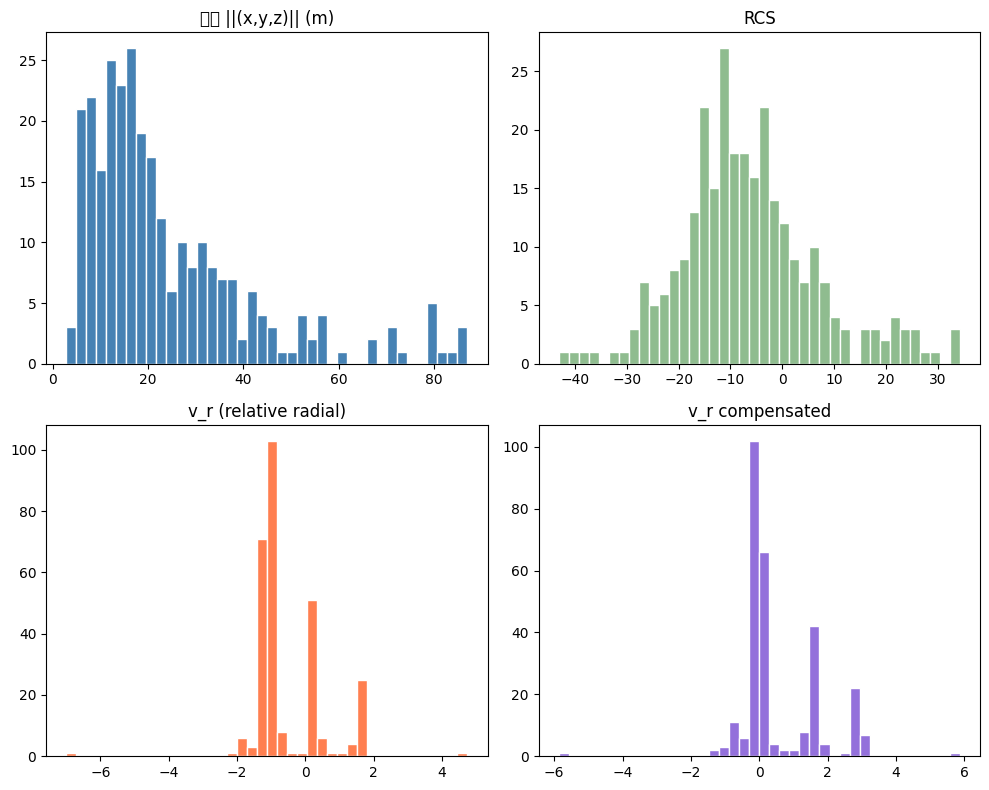

In [24]:
loader = FrameDataLoader(kitti_locations=kitti, frame_number=FRAME_ID)
rad = loader.radar_data
assert rad is not None and rad.ndim == 2 and rad.shape[1] == 7, rad.shape

xyz = rad[:, :3]
rng = np.linalg.norm(xyz, axis=1)

print("포인트 수:", rad.shape[0])
print("거리(m) min/median/max:", float(np.min(rng)), float(np.median(rng)), float(np.max(rng)))
print("RCS min/max:", float(np.min(rad[:, 3])), float(np.max(rad[:, 3])))
print("v_r (상대) min/max:", float(np.min(rad[:, 4])), float(np.max(rad[:, 4])))
print("v_r_compensated min/max:", float(np.min(rad[:, 5])), float(np.max(rad[:, 5])))
print("time 고유값:", np.unique(rad[:, 6]))

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0, 0].hist(rng, bins=40, color="steelblue", edgecolor="white")
ax[0, 0].set_title("거리 ||(x,y,z)|| (m)")
ax[0, 1].hist(rad[:, 3], bins=40, color="darkseagreen", edgecolor="white")
ax[0, 1].set_title("RCS")
ax[1, 0].hist(rad[:, 4], bins=40, color="coral", edgecolor="white")
ax[1, 0].set_title("v_r (relative radial)")
ax[1, 1].hist(rad[:, 5], bins=40, color="mediumpurple", edgecolor="white")
ax[1, 1].set_title("v_r compensated")
plt.tight_layout()
plt.show()

## 3) 카메라 이미지 로드 및 간단 통계

shape (H,W,C): (1216, 1936, 3) dtype: uint8


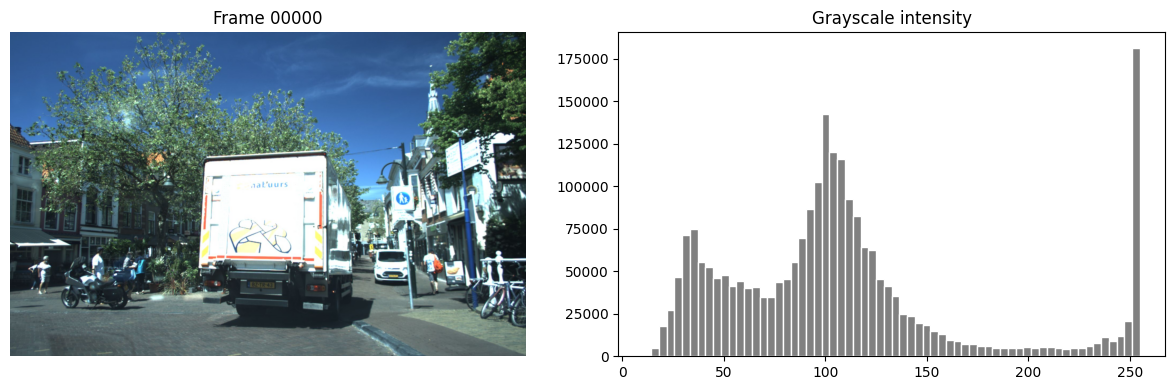

In [25]:
img = loader.image
assert img is not None
print("shape (H,W,C):", img.shape, "dtype:", img.dtype)

gray = img.mean(axis=2) if img.ndim == 3 else img
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(img)
ax[0].set_title(f"Frame {FRAME_ID}")
ax[0].axis("off")
ax[1].hist(gray.ravel(), bins=64, color="gray", edgecolor="white")
ax[1].set_title("Grayscale intensity")
plt.tight_layout()
plt.show()

## 4) 레이더 → 카메라 투영 (캘리브·동기 검증)

`FrameTransformMatrix`는 내부적으로 **카메라 P** 를 `lidar/training/calib` 에서 읽습니다.  
lidar calib 이 없으면 아래 **fallback** 으로 radar calib 의 P2 를 사용합니다.

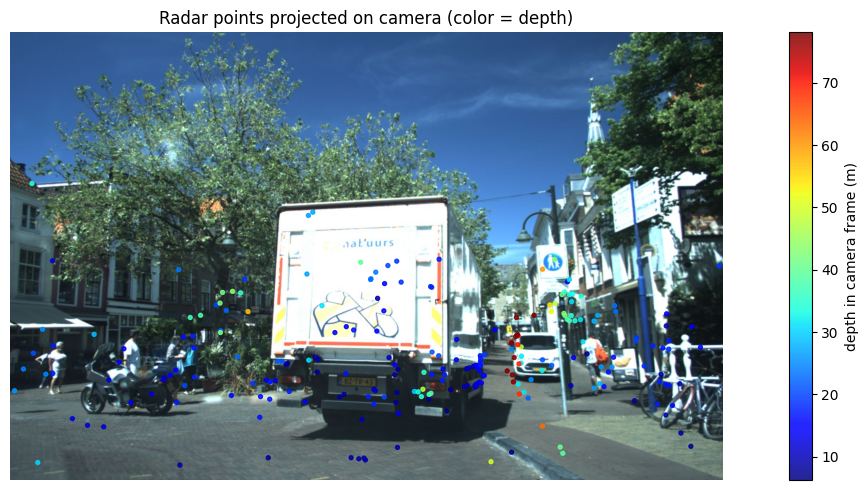

이미지 안에 투영된 점 수: 234 / 284


In [26]:
def load_p2_from_calib(calib_path: str) -> np.ndarray:
    """KITTI 텍스트 3번째 줄 P2 → 3x4 투영 행렬."""
    with open(calib_path, "r") as f:
        lines = f.readlines()
    return np.array(lines[2].strip().split()[1:], dtype=np.float32).reshape(3, 4)


ft = FrameTransformMatrix(loader)
T_cr = ft.t_camera_radar

if st["lidar_calib_txt"]:
    P = ft.camera_projection_matrix
else:
    P = load_p2_from_calib(st["paths"]["radar_calib"])
    print("P 행렬: radar calib 에서 로드")

uvs, depth = project_pcl_to_image(
    point_cloud=rad,
    t_camera_pcl=T_cr,
    camera_projection_matrix=P,
    image_shape=img.shape,
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(img)
dmax = float(np.percentile(depth, 98)) if len(depth) else 1.0
sc = ax.scatter(
    uvs[:, 0],
    uvs[:, 1],
    c=depth,
    cmap="jet",
    s=8,
    alpha=0.85,
    vmin=float(depth.min()) if len(depth) else 0,
    vmax=max(dmax, 1e-3),
)
plt.colorbar(sc, ax=ax, fraction=0.025, label="depth in camera frame (m)")
ax.set_title("Radar points projected on camera (color = depth)")
ax.axis("off")
plt.tight_layout()
plt.show()
print("이미지 안에 투영된 점 수:", len(uvs), "/", rad.shape[0])

## 5) 2D 테스트: 거리 vs 도플러 (레이더만)

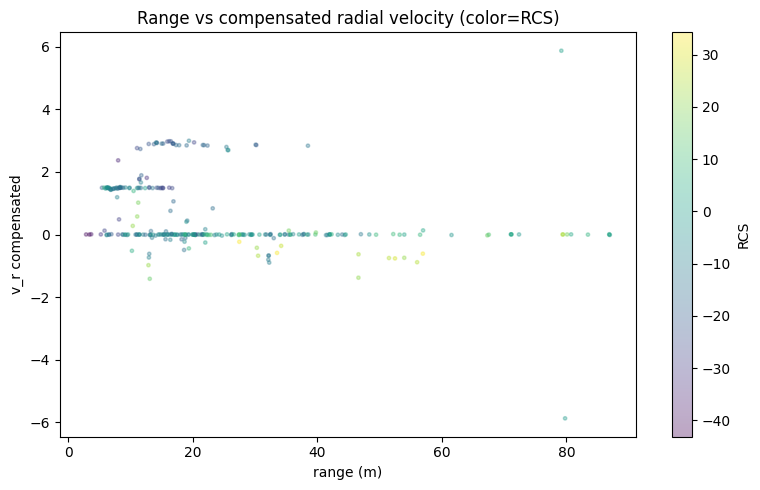

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
sc2 = ax.scatter(rng, rad[:, 5], s=6, alpha=0.35, c=rad[:, 3], cmap="viridis")
ax.set_xlabel("range (m)")
ax.set_ylabel("v_r compensated")
ax.set_title("Range vs compensated radial velocity (color=RCS)")
plt.colorbar(sc2, ax=ax, label="RCS")
plt.tight_layout()
plt.show()

## 6) 시퀀스: 사용 가능한 프레임에서 레이더 포인트 수 추이

`image_2` 와 `radar/.../velodyne` 에 **공통으로 존재하는** 프레임만 집계합니다.

In [28]:
def list_matched_frames(loc: KittiLocations) -> list[str]:
    cam_dir = Path(loc.camera_dir)
    rad_dir = Path(loc.radar_dir)
    if not cam_dir.is_dir() or not rad_dir.is_dir():
        return []
    jpgs = {p.stem for p in cam_dir.glob("*.jpg")}
    bins = {p.stem for p in rad_dir.glob("*.bin")}
    common = sorted(jpgs & bins, key=lambda s: int(s))
    return common


frames = list_matched_frames(kitti)
print("매칭된 프레임 수:", len(frames))
if len(frames) < 2:
    print("프레임이 부족하면 이 섹션은 건너뜁니다.")
else:
    counts = []
    for fr in frames:
        p = os.path.join(kitti.radar_dir, f"{fr.zfill(5)}.bin")
        arr = np.fromfile(p, dtype=np.float32)
        counts.append(arr.size // 7)
    fig, ax = plt.subplots(figsize=(max(8, len(frames) * 0.15), 4))
    ax.bar(range(len(frames)), counts, color="steelblue")
    ax.set_xticks(range(len(frames)))
    ax.set_xticklabels(frames, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("radar points")
    ax.set_title("Points per frame (radar only)")
    plt.tight_layout()
    plt.show()

매칭된 프레임 수: 8682


---
### 큰 데이터셋 (`vod-received` 등) 사용 시

환경 변수로 루트만 바꿔도 됩니다.

```bash
set VOD_ROOT=C:\Users\...\vod-received\view_of_delft_PUBLIC
jupyter notebook 5_radar_camera_only_tests.ipynb
```

VoD 공식 구조에서는 카메라가 `lidar/training/image_2` 에 있습니다 (레이더 전용 트리와 동기).